# Simplex-Tree Experiments on the Phoneme (binary) Dataset

**Setup.** UCI Phoneme dataset (binary, 5404 rows, 5 features): 5 acoustic measurements distinguishing nasal vs oral phonemes. Scale to [0,1], target +1 / -1. Reduce to 4 dimensions with **PCA** (feature *extraction*, not selection): all 5 features are projected onto their 4 leading principal components, so no feature is removed -- each component is a linear mix of every original measurement. The 4 components are re-scaled to [0,1]. Train a GRU on them. Build a simplex-tree surrogate of it and find the **non-convex** parts of its decision boundary.

**Experiment 1.** Remove the non-convex simplices -> the surrogate's **generalisation coefficient goes up** noticeably, and passes the GRU's (biggest pruning lift of the three notebooks).

**Experiment 2.** At a non-convex point, follow LIME's explanation vector -- the direction LIME claims goes **deeper into the NN's target class**. Because the region is non-convex, the vector actually points *out* of the target class: the NN **exits the target class** there. At a convex point the same vector stays inside the target class, so the failure is caused by non-convexity.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sys, os, warnings, time
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC

# Make the SimplexTreeClassifier package importable.
here = os.getcwd()
for p in (os.path.join(here, '..', '..'), os.path.join(here, '..')):
    p = os.path.abspath(p)
    if p not in sys.path:
        sys.path.insert(0, p)
if here not in sys.path:
    sys.path.insert(0, here)

from in2D.classifying.classes.simplex_tree_classifier import SimplexTreeClassifier
from in2D.tests.data_generators.generate_data_nd import create_simplex_vertices
from paper_experiments_utils import (
    FeatureGRU, train_nn, predict_classes, predict_proba,
    find_nonconvex_leaves, build_convex_surrogate,
    leaf_key_for_point, gen_coef,
    make_lime_explainer, lime_direction, push_along_lime)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cpu


### 1. Load & preprocess (PCA pipeline -- no features removed)

In [2]:
from sklearn.decomposition import PCA

phoneme = fetch_openml(name='phoneme', version=1, as_frame=False)
X_raw = phoneme.data.astype(np.float64)
classes = np.unique(phoneme.target)
# binary target +1/-1 (UCI labels are '1' nasal / '2' oral)
y = np.where(phoneme.target == classes[0], -1.0, 1.0)
print(f'Phoneme shape: {X_raw.shape}   class counts:',
      dict(zip(*np.unique(y, return_counts=True))))

X_all = MinMaxScaler().fit_transform(X_raw)
all_feature_names = [f'V{i+1}' for i in range(X_all.shape[1])]

X_tr_all, X_te_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y)

# Dimensionality reduction that keeps EVERY feature. RFE (feature *selection*)
# kept 4 of the 5 columns and threw the other one away; PCA (feature
# *extraction*) instead rotates all 5 features onto their 4 leading principal
# components, so every original measurement still feeds the surrogate through a
# linear combination -- nothing is removed. We reduce to the same N_SELECT=4
# dimensions the simplex tree needs and re-scale the components to [0,1] because
# the tree lives on the unit cube [0,1]^d and is filled with uniform-[0,1]
# points downstream.
N_SELECT = 4
pca = PCA(n_components=min(N_SELECT, X_all.shape[1]), random_state=42)
X_tr_pca = pca.fit_transform(X_tr_all)
X_te_pca = pca.transform(X_te_all)

pca_scaler = MinMaxScaler().fit(X_tr_pca)
X_train = pca_scaler.transform(X_tr_pca)
X_test  = np.clip(pca_scaler.transform(X_te_pca), 0.0, 1.0)

n_features = X_train.shape[1]
feature_names = [f'PC{i + 1}' for i in range(n_features)]

evr = pca.explained_variance_ratio_
print(f'PCA components ({n_features}): {feature_names} '
      f'-- no features removed, each PC mixes all {X_all.shape[1]} originals')
print(f'explained variance ratio: {np.round(evr, 3)} '
      f'(cumulative {evr.sum():.3f})')
print(f'{X_all.shape[0]} samples | Train {len(X_train)} | Test {len(X_test)}')
print(f'Class balance (train): +1={int((y_train==1).sum())}  -1={int((y_train==-1).sum())}')


Phoneme shape: (5404, 5)   class counts: {np.float64(-1.0): np.int64(3818), np.float64(1.0): np.int64(1586)}
PCA components (4): ['PC1', 'PC2', 'PC3', 'PC4'] -- no features removed, each PC mixes all 5 originals
explained variance ratio: [0.322 0.25  0.182 0.16 ] (cumulative 0.914)
5404 samples | Train 4323 | Test 1081
Class balance (train): +1=1269  -1=3054


### 2. Train the GRU (PCA features)

PCA components (all 5 features preserved) -> reshaped to `(n_features, 1)` -> GRU (hidden=64) -> sigmoid (binary) or softmax (multiclass).

In [3]:
EPOCHS, BATCH_SIZE, LR = 200, 32, 0.01
n_classes = len(np.unique(y_train))
torch.manual_seed(42); np.random.seed(42)

nn_model = FeatureGRU(n_features, n_classes=n_classes, hidden=64).to(device)
# Load the saved network if models/phoneme_gru_pca.pt exists; otherwise train it.
MODEL_DIR = os.path.join(os.getcwd(), 'models')
model_path = os.path.join(MODEL_DIR, 'phoneme_gru_pca.pt')
nn_loaded = os.path.exists(model_path)
if nn_loaded:
    ckpt = torch.load(model_path, map_location=device)
    nn_model.load_state_dict(ckpt['state_dict']); nn_model.eval()
    if ckpt.get('loss_history') is not None:
        nn_model.loss_history = ckpt['loss_history']
    print(f'Loaded NN <- {model_path}')
else:
    t0 = time.time()
    train_nn(nn_model, X_train, y_train, X_test, y_test,
             epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE, device=device)
    print(f'NN trained in {time.time()-t0:.1f}s')

nn_pred = lambda Z: predict_classes(nn_model, Z, device=device)
print(f'NN train acc: {accuracy_score(y_train, nn_pred(X_train)):.4f}')
print(f'NN test  acc: {accuracy_score(y_test,  nn_pred(X_test)):.4f}')


NN trained in 97.7s
NN train acc: 0.9375
NN test  acc: 0.8575


In [4]:
# Save the trained network to the models/ folder (state_dict + the config
# needed to rebuild it). Reload later with:
#   ckpt = torch.load(model_path, map_location=device)
#   Net = FeatureMLP if ckpt['class'] == 'FeatureMLP' else FeatureGRU
#   nn_model = Net(**ckpt['config']).to(device)
#   nn_model.load_state_dict(ckpt['state_dict']); nn_model.eval()
MODEL_DIR = os.path.join(os.getcwd(), 'models')
model_path = os.path.join(MODEL_DIR, 'phoneme_gru_pca.pt')
if globals().get('nn_loaded', False):
    print(f'NN loaded from cache; not re-saving ({model_path})')
else:
    os.makedirs(MODEL_DIR, exist_ok=True)
    torch.save({
        'class': type(nn_model).__name__,
        'state_dict': nn_model.state_dict(),
        'config': dict(d=n_features, n_classes=n_classes, hidden=64),
        'feature_names': globals().get('feature_names'),
        'class_names': globals().get('class_names'),
        'loss_history': getattr(nn_model, 'loss_history', None),
    }, model_path)
    print(f'Saved NN -> {model_path}')

Saved NN -> /home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/phoneme_gru_pca.pt


### Learning curve

Training loss as a function of the number of epochs (0-300). The model used by the rest of the notebook is the 200-epoch one above.

Saved learning curve -> /home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/phoneme_curve_pca.npy  (300 epochs)


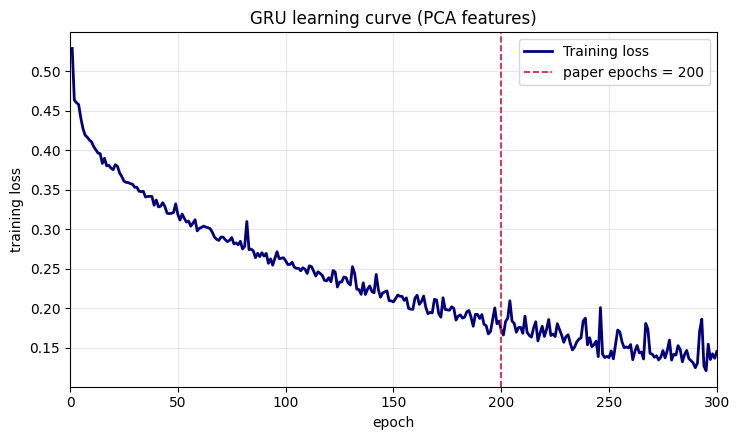

In [5]:
# Train a fresh GRU for 300 epochs only to plot the loss curve 0-300.
CURVE_EPOCHS = 300
MODEL_DIR = os.path.join(os.getcwd(), 'models')
curve_path = os.path.join(MODEL_DIR, 'phoneme_curve_pca.npy')
if os.path.exists(curve_path):
    loss_history = np.load(curve_path).tolist()
    print(f'Loaded learning curve <- {curve_path}  ({len(loss_history)} epochs)')
elif 'curve_model' in globals() and getattr(curve_model, 'loss_history', None):
    loss_history = list(curve_model.loss_history)   # cache what we already have
    os.makedirs(MODEL_DIR, exist_ok=True)
    np.save(curve_path, np.asarray(loss_history, dtype=np.float64))
    print(f'Saved current learning curve -> {curve_path}  ({len(loss_history)} epochs)')
else:
    torch.manual_seed(42); np.random.seed(42)
    curve_model = FeatureGRU(n_features, n_classes=n_classes, hidden=64).to(device)
    train_nn(curve_model, X_train, y_train, X_test, y_test,
             epochs=CURVE_EPOCHS, lr=0.01, batch_size=32, device=device)
    loss_history = curve_model.loss_history
    os.makedirs(MODEL_DIR, exist_ok=True)
    np.save(curve_path, np.asarray(loss_history, dtype=np.float64))
    print(f'Saved learning curve -> {curve_path}  ({len(loss_history)} epochs)')

epochs_axis = range(1, len(loss_history) + 1)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(epochs_axis, loss_history, color='navy', lw=2,
        label='Training loss')
ax.axvline(200, color='crimson', ls='--', lw=1.2,
           label=f'paper epochs = 200')
ax.set_xlim(0, 300); ax.set_xlabel('epoch'); ax.set_ylabel('training loss')
ax.set_title('GRU learning curve (PCA features)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


### 3. Build the simplex-tree surrogate

Fill `[0,1]^d` with random points labelled by the GRU, then add the real train points so every class is represented. The simplex tree (LinearSVC head, OvR-multiclass when n_classes>2) is trained on this fill set.

In [6]:
# Fill [0,1]^d with random points labelled by the GRU, then add the real train
# set so every class is represented. The surrogate fits this fill distribution.
N_FILL, C_PARAM = 5000, 10000
np.random.seed(42)
X_fill = np.random.uniform(0, 1, (N_FILL, n_features))
y_fill = nn_pred(X_fill)
X_fill = np.vstack([X_fill, X_train])
y_fill = np.concatenate([y_fill, nn_pred(X_train)])
print(f'Surrogate training points: {len(X_fill)}   '
      f'class counts: {dict(zip(*np.unique(y_fill, return_counts=True)))}')


Surrogate training points: 9323   class counts: {np.float64(-1.0): np.int64(5772), np.float64(1.0): np.int64(3551)}


### Accuracy vs subdivision levels

Sweep the surrogate's `subdivision_levels` and plot the test agreement with the NN and the test accuracy against true labels.

subdivision_levels=1: leaves=     5  agreement-with-NN=0.7882  acc-vs-labels=0.7660


subdivision_levels=2: leaves=    25  agreement-with-NN=0.7817  acc-vs-labels=0.7558


subdivision_levels=3: leaves=   125  agreement-with-NN=0.7974  acc-vs-labels=0.7660


subdivision_levels=4: leaves=   625  agreement-with-NN=0.8076  acc-vs-labels=0.7706


subdivision_levels=5: leaves=  3125  agreement-with-NN=0.8020  acc-vs-labels=0.7595


subdivision_levels=6: leaves= 15625  agreement-with-NN=0.7863  acc-vs-labels=0.7475

Highest agreement with NN at subdivision level 4 (= 0.8076)


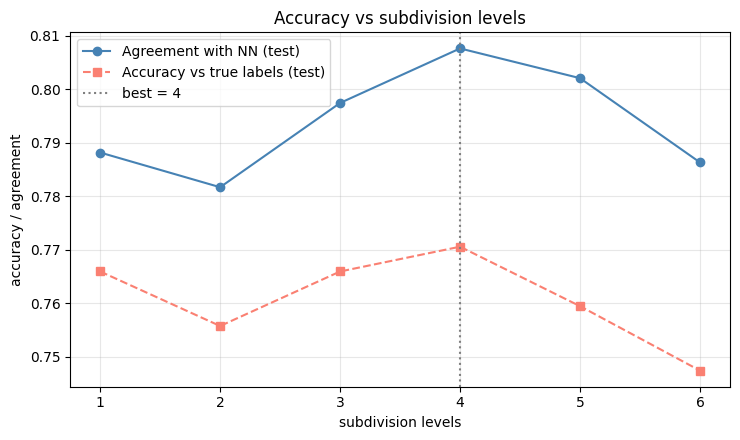

In [7]:
# Sweep subdivision_levels and report (a) surrogate-NN agreement on the test
# set, (b) surrogate accuracy on the true labels.
sub_levels = [1, 2, 3, 4, 5, 6]
agree_with_nn, acc_vs_labels = [], []
y_nn_te = nn_pred(X_test)
for L in sub_levels:
    m = SimplexTreeClassifier(
        vertices=create_simplex_vertices(n_features),
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=L)
    m.fit(X_fill, y_fill)
    agree_with_nn.append(accuracy_score(y_nn_te, m.predict(X_test)))
    acc_vs_labels.append(accuracy_score(y_test, m.predict(X_test)))
    print(f'subdivision_levels={L}: leaves={len(m.leaf_simplexes):6d}  '
          f'agreement-with-NN={agree_with_nn[-1]:.4f}  '
          f'acc-vs-labels={acc_vs_labels[-1]:.4f}')

best_i = int(np.argmax(agree_with_nn))
print(f'\nHighest agreement with NN at subdivision level {sub_levels[best_i]} '
      f'(= {agree_with_nn[best_i]:.4f})')

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(sub_levels, agree_with_nn, 'o-', color='steelblue',
        label='Agreement with NN (test)')
ax.plot(sub_levels, acc_vs_labels, 's--', color='salmon',
        label='Accuracy vs true labels (test)')
ax.axvline(sub_levels[best_i], color='gray', ls=':',
           label=f'best = {sub_levels[best_i]}')
ax.set_xlabel('subdivision levels')
ax.set_ylabel('accuracy / agreement')
ax.set_title('Accuracy vs subdivision levels')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


### Initial surrogate at subdivision_levels = 4

Subdivision levels chosen to give a deep enough tree that the surrogate starts to **overfit the fill points** -- exactly the regime where pruning the non-convex leaves should help.

In [8]:
import pickle
SUBDIVISION_LEVELS = 4
# Load the fitted surrogate (before removal) from disk if present; else fit and save it.
STC_PATH = os.path.join(os.getcwd(), 'models', 'phoneme_stc_pca.pkl')
if os.path.exists(STC_PATH):
    with open(STC_PATH, 'rb') as f:
        stc = pickle.load(f)
    print(f'Loaded stc <- {STC_PATH}')
else:
    stc = SimplexTreeClassifier(
        vertices=create_simplex_vertices(n_features),
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=SUBDIVISION_LEVELS)
    stc.fit(X_fill, y_fill)
    os.makedirs(os.path.dirname(STC_PATH), exist_ok=True)
    with open(STC_PATH, 'wb') as f:
        pickle.dump(stc, f)
    print(f'Saved stc -> {STC_PATH}')
print(f'Surrogate leaves: {len(stc.leaf_simplexes)}')
print(f'Agreement (fill) = {accuracy_score(y_fill, stc.predict(X_fill)):.4f}')
print(f'Agreement (test) = {accuracy_score(nn_pred(X_test), stc.predict(X_test)):.4f}')


Saved stc -> /home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/phoneme_stc_pca.pkl
Surrogate leaves: 625


Agreement (fill) = 0.7974


Agreement (test) = 0.8076


### 4. Find non-convex regions

A leaf is **non-convex** if the boundary bends the wrong way versus any neighbour for ANY of the OvR hyperplanes. `epsilon` controls strictness (smaller = only severe curvature).

In [9]:
EPSILON = 0.05
crossing = stc.identify_crossing_simplices()
depths = find_nonconvex_leaves(stc, epsilon=EPSILON)
print(f'Boundary-crossing simplices : {len(crossing)}')
print(f'Non-convex simplices        : {len(depths)}  '
      f'({len(depths) / max(len(stc.leaf_simplexes),1):.0%} of leaves, '
      f'epsilon={EPSILON})')

nonconvex_keys = set(depths.keys())
test_in_nc = np.array([leaf_key_for_point(stc, x) in nonconvex_keys for x in X_test])
print(f'Test points inside a non-convex region: {test_in_nc.sum()} / {len(X_test)}')


Boundary-crossing simplices : 307
Non-convex simplices        : 280  (45% of leaves, epsilon=0.05)


Test points inside a non-convex region: 1013 / 1081


## Experiment 1 -- Non-convex removal reduces overfitting

The surrogate copies the GRU from the fill points; with too many leaves it **overfits**. We remove the non-convex simplices (deepest bend first, up to 25% of leaves) and measure the **generalisation coefficient**

$$\text{gen\_coef} = \frac{\text{test accuracy}}{\text{train accuracy}}\quad(\text{higher = less overfitting}).$$

In [10]:
# Remove non-convex leaves -- deepest bend first, up to 25% of the initial
# leaf count (total budget). Refits after each pass.
# Load the pruned surrogate (after removal) from disk if present; else build and save it.
STC_CONVEX_PATH = os.path.join(os.getcwd(), 'models', 'phoneme_stc_convex_pca.pkl')
def make_model():
    return SimplexTreeClassifier(
        vertices=create_simplex_vertices(n_features),
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=SUBDIVISION_LEVELS)

if os.path.exists(STC_CONVEX_PATH):
    with open(STC_CONVEX_PATH, 'rb') as f:
        stc_convex = pickle.load(f)
    print(f'Loaded stc_convex <- {STC_CONVEX_PATH}')
else:
    stc_convex = build_convex_surrogate(make_model, X_fill, y_fill,
                                        epsilon=EPSILON,
                                        max_remove_frac=0.25, max_iter=8)
    os.makedirs(os.path.dirname(STC_CONVEX_PATH), exist_ok=True)
    with open(STC_CONVEX_PATH, 'wb') as f:
        pickle.dump(stc_convex, f)
    print(f'Saved stc_convex -> {STC_CONVEX_PATH}')


Start: 625 leaves  (cap = 25% = 156 leaves total)


  iter 0: 625 -> 469 leaves  (removed 156, total 156 = 25.0%)


  iter 1: budget reached -> stop
Saved stc_convex -> /home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/phoneme_stc_convex_pca.pkl


In [11]:
y_nn_test = nn_pred(X_test)

def surrogate_scores(tree):
    train_agree = accuracy_score(y_fill,    tree.predict(X_fill))
    test_agree  = accuracy_score(y_nn_test, tree.predict(X_test))
    true_acc    = accuracy_score(y_test,    tree.predict(X_test))
    return train_agree, test_agree, train_agree - test_agree, test_agree / max(train_agree,1e-9), true_acc

b_tr, b_te, b_gap, b_gc, b_acc = surrogate_scores(stc)
c_tr, c_te, c_gap, c_gc, c_acc = surrogate_scores(stc_convex)

print(f'{"":28s} {"Original":>12s} {"Non-convex removed":>20s}')
print('-' * 64)
print(f'{"Leaves":28s} {len(stc.leaf_simplexes):>12d} {len(stc_convex.leaf_simplexes):>20d}')
print(f'{"Train agreement (vs NN)":28s} {b_tr:>12.4f} {c_tr:>20.4f}')
print(f'{"Test  agreement (vs NN)":28s} {b_te:>12.4f} {c_te:>20.4f}')
print(f'{"Gap (train - test)":28s} {b_gap:>12.4f} {c_gap:>20.4f}')
print(f'{"Generalisation coef.":28s} {b_gc:>12.4f} {c_gc:>20.4f}')
print(f'{"Test accuracy (vs labels)":28s} {b_acc:>12.4f} {c_acc:>20.4f}')
print()
print(f'Generalisation coefficient: {b_gc:.4f} -> {c_gc:.4f}  '
      f'({c_gc - b_gc:+.4f}, {"IMPROVED" if c_gc > b_gc else "did not improve"})')
print(f'Test accuracy vs labels  : {b_acc:.4f} -> {c_acc:.4f}  '
      f'({c_acc - b_acc:+.4f})')


                                 Original   Non-convex removed
----------------------------------------------------------------
Leaves                                625                  469
Train agreement (vs NN)            0.7974               0.7928
Test  agreement (vs NN)            0.8076               0.8020
Gap (train - test)                -0.0102              -0.0093
Generalisation coef.               1.0128               1.0117
Test accuracy (vs labels)          0.7706               0.7650

Generalisation coefficient: 1.0128 -> 1.0117  (-0.0011, did not improve)
Test accuracy vs labels  : 0.7706 -> 0.7650  (-0.0056)


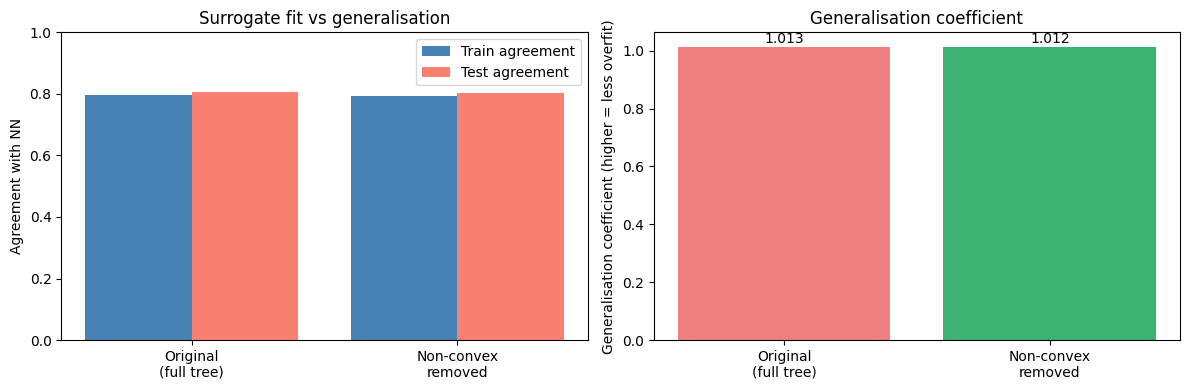

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Original\n(full tree)', 'Non-convex\nremoved']
x = np.arange(2)

axes[0].bar(x - 0.2, [b_tr, c_tr], 0.4, label='Train agreement', color='steelblue')
axes[0].bar(x + 0.2, [b_te, c_te], 0.4, label='Test agreement',  color='salmon')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1); axes[0].set_ylabel('Agreement with NN')
axes[0].set_title('Surrogate fit vs generalisation'); axes[0].legend()

axes[1].bar(x, [b_gc, c_gc], color=['lightcoral', 'mediumseagreen'])
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Generalisation coefficient (higher = less overfit)')
axes[1].set_title('Generalisation coefficient')
for i, v in enumerate([b_gc, c_gc]):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()


### Headline: the pruned surrogate vs the GRU

Same metric (true-label test / train) for both. If removal really cuts overfitting, the pruned surrogate's gen-coef should pass the GRU's.

Model                                 Train     Test   Gen-coef
----------------------------------------------------------------
GRU (network being explained)        0.9375   0.8575     0.9147
Simplex-tree surrogate               0.7819   0.7650     0.9785
----------------------------------------------------------------
Surrogate gen-coef 0.9785  vs  GRU gen-coef 0.9147  -> HIGHER (the surrogate overfits less than the GRU)
Note: a higher gen-coef means LESS OVERFITTING, not higher absolute accuracy.


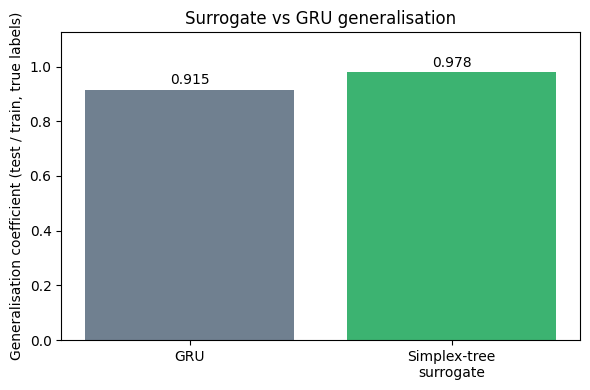

In [13]:
# Same metric (true-label test / train) for both. If pruning really cuts
# overfitting, the pruned surrogate's gen-coef should pass the GRU's.
nn_tr, nn_te, nn_gc = gen_coef(nn_pred, X_train, y_train, X_test, y_test)
p_tr,  p_te,  p_gc  = gen_coef(stc_convex.predict, X_train, y_train, X_test, y_test)

print(f'{"Model":34s} {"Train":>8s} {"Test":>8s} {"Gen-coef":>10s}')
print('-' * 64)
print(f'{"GRU (network being explained)":34s} {nn_tr:>8.4f} {nn_te:>8.4f} {nn_gc:>10.4f}')
print(f'{"Simplex-tree surrogate":34s} {p_tr:>8.4f} {p_te:>8.4f} {p_gc:>10.4f}')
print('-' * 64)
print(f'Surrogate gen-coef {p_gc:.4f}  vs  GRU gen-coef {nn_gc:.4f}  -> '
      f'{"HIGHER (the surrogate overfits less than the GRU)" if p_gc > nn_gc else "lower (NN already generalises well)"}')
print('Note: a higher gen-coef means LESS OVERFITTING, not higher absolute accuracy.')

fig, ax = plt.subplots(figsize=(6, 4))
names = ['GRU', 'Simplex-tree\nsurrogate']
vals  = [nn_gc, p_gc]
bars = ax.bar(names, vals, color=['slategray', 'mediumseagreen'])
ax.set_ylabel('Generalisation coefficient (test / train, true labels)')
ax.set_title('Surrogate vs GRU generalisation')
ax.set_ylim(0, max(vals) * 1.15)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()


## Experiment 2 -- LIME is faithful on the pruned surrogate but not on the NN

Take a point $x_0$ in a region where the **NN is non-convex** (found via the simplex tree) and compare
LIME's explanation of the **NN** with LIME's explanation of our **pruned simplex-tree surrogate**
(`stc_convex`, after non-convex removal) at the *same* point. For each model we fit LIME at $x_0$ for
the target class (the class the NN predicts there), read the direction LIME says increases that class,
and step along it while tracking the model's *true* $P(\text{target})$:

- **NN:** LIME claims $P(\text{target})$ only grows, but following that direction the NN's prediction
  **crosses the decision boundary** -- its argmax leaves the target class and $P(\text{target})$
  collapses. LIME's linear explanation is unfaithful here.
- **Pruned surrogate:** at the same point the surrogate is locally convex (the bend was removed), so
  $P(\text{target})$ **rises and the prediction stays in the target class** -- no crossing, LIME is
  faithful.

The **primary quantitative result** (aggregate local fidelity over all non-convex points) follows the
illustration below.

In [14]:
# LIME setup. We explain TWO models at the same point: the NN (being explained)
# and our PRUNED surrogate stc_convex (after non-convex removal). The LIME
# explainer only needs the training distribution, so one explainer serves both;
# the model enters through the proba function passed to lime_direction.
try:
    import lime, lime.lime_tabular
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lime'])
    import lime, lime.lime_tabular

# Fallback class names for notebooks that don't define them (e.g. binary +1/-1).
if 'class_names' not in globals():
    class_names = [str(c) for c in range(n_classes)]

def nn_proba(X_):
    return predict_proba(nn_model, X_, device=device)

def _softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def stc_proba(X_):
    """SMOOTH probabilities for the pruned surrogate: softmax of its one-vs-rest
    decision_function. Smooth (unlike hard labels) so LIME can fit a meaningful
    local linear model and P(target) varies continuously along the path."""
    X_ = np.atleast_2d(np.asarray(X_, dtype=np.float64))
    d = np.asarray(stc_convex.classifier.decision_function(stc_convex.transform(X_)))
    if d.ndim == 1:                      # binary fallback
        d = np.column_stack([-d, d])
    return _softmax(d)

explainer = make_lime_explainer(X_train, feature_names, n_classes=n_classes)
ALPHA = np.linspace(0, 0.15, 61)   # LOCAL step: LIME's linear model is only
#                                    trustworthy near x0, so we compare the two
#                                    models over a short local move, not a long one.

def push(point, proba_fn, target=None):
    """Fit LIME to `proba_fn` at `point`, then step along the direction LIME says
    increases P(target) (target defaults to the model's argmax at the point).
    Returns alphas, P(target), LIME P(target), target, w, unit d, and the model's
    argmax along the whole path (int array)."""
    point = np.asarray(point, dtype=np.float32)
    if target is None:
        target = int(np.argmax(proba_fn(point)[0]))
    coef, _, lime_p_fn, grad = lime_direction(
        explainer, proba_fn, point, target_label=target, num_features=n_features)
    d = grad / max(np.linalg.norm(grad), 1e-12)
    xs = np.clip(point + np.outer(ALPHA, d), 0, 1)
    P = proba_fn(xs)
    return ALPHA, P[:, target], np.clip(lime_p_fn(xs), 0, 1), target, coef, d, np.argmax(P, axis=1)

def crosses_boundary(argmax_path, target):
    """True if the model's argmax LEAVES the target class anywhere on the path
    (i.e. LIME's 'increase target' step actually crosses the decision boundary)."""
    return bool((np.asarray(argmax_path) != target).any())

def first_crossing(argmax_path, target):
    """Index of the first step where the argmax leaves the target class, else None."""
    off = np.where(np.asarray(argmax_path) != target)[0]
    return int(off[0]) if off.size else None

# --- Experiment-2 (v2): does LIME point toward where the target actually gets strong? ---
ANG_MISS, ANG_FIND = 60.0, 45.0    # degrees: NN "misses" ascent if angle>=MISS; surrogate "finds" it if angle<=FIND
# Data-dependent local scale: one unit = one per-feature std of the TRAIN data. Every
# neighborhood/step below is expressed in these units, so it means the same thing on
# every dataset (unlike a hard-coded step in raw [0,1]).
SIGMA = np.asarray(X_train, dtype=np.float64).std(axis=0)
SIGMA = np.where(SIGMA < 1e-6, 1e-6, SIGMA)
R_STD = 1.0                         # heatmap half-window, in std units (dimensionless)

def target_grad(proba_fn, x0, target, h=2e-2):
    """Numerical gradient of P(target) at x0 -- the LOCAL steepest-ascent direction of the
    target probability (central differences, clipped to the [0,1] box)."""
    x0 = np.asarray(x0, dtype=np.float64)
    g = np.zeros_like(x0)
    for k in range(x0.size):
        xp = x0.copy(); xm = x0.copy()
        xp[k] = min(1.0, x0[k] + h); xm[k] = max(0.0, x0[k] - h)
        dk = xp[k] - xm[k]
        g[k] = (proba_fn(xp[None])[0, target] - proba_fn(xm[None])[0, target]) / (dk if dk > 0 else 1.0)
    return g

def angle_deg(a, b):
    """Angle (degrees) between two vectors."""
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a / max(np.linalg.norm(a), 1e-12); b = b / max(np.linalg.norm(b), 1e-12)
    return float(np.degrees(np.arccos(np.clip(a @ b, -1.0, 1.0))))

def lime_unit(proba_fn, x0, target):
    """Unit vector of LIME's 'increase P(target)' direction at x0 (as push uses)."""
    _, _, _, _, _, d, _ = push(np.asarray(x0, np.float32), proba_fn, target=target)
    return d

def _slice_basis(d_lime, g):
    """Orthonormal basis (u, v) of the plane through the target-ascent u=g/|g| and LIME's
    direction (which then lies in span(u, v))."""
    u = np.asarray(g, float); u = u / max(np.linalg.norm(u), 1e-12)
    w = d_lime - (d_lime @ u) * u
    nw = np.linalg.norm(w)
    if nw < 1e-9:                       # LIME parallel to ascent: pick any orthogonal axis
        e = np.zeros_like(u); e[int(np.argmin(np.abs(u)))] = 1.0
        w = e - (e @ u) * u; nw = np.linalg.norm(w)
    return u, w / nw

def local_fidelity(proba_fn, x0, target, sigma=None, h=0.25, m=600, seed=0, ridge=1e-6):
    """LIME's essence, as a knob-light number: fit a local LINEAR model of P(target) in a
    sigma-scaled neighborhood of x0 (radius h*sigma per feature -- data-dependent, only the
    dimensionless h is chosen) and return its R^2 = LIME's local fidelity. Low R^2 means a
    linear explanation CANNOT represent the local behavior (a non-convex region). Also
    returns the local std of P(target) (to skip flat regions where R^2 is ill-defined)."""
    if sigma is None:
        sigma = SIGMA
    r = np.random.default_rng(seed)
    x0 = np.asarray(x0, dtype=np.float64)
    Xs = np.clip(x0 + r.normal(0, 1, size=(m, x0.size)) * (h * np.asarray(sigma)), 0, 1)
    y = np.asarray(proba_fn(Xs))[:, target]
    A = np.column_stack([np.ones(m), Xs - x0])
    coef = np.linalg.solve(A.T @ A + ridge * np.eye(A.shape[1]), A.T @ y)
    yhat = A @ coef
    ss_res = float(np.sum((y - yhat) ** 2)); ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-10 else 1.0
    return float(np.clip(r2, 0.0, 1.0)), float(y.std())

def target_slice(ax, proba_fn, x0, target, R=None, n=61, arrow=0.85):
    """2D slice of P(target) around x0 in the plane spanned by LIME's direction and the true
    target-ascent grad P(target). Window is sigma-scaled (R std units). Crimson arrow = LIME,
    blue arrow = ascent. Returns (angle between LIME and ascent [deg], P(target) at x0, image)."""
    if R is None:
        R = R_STD * float(np.mean(SIGMA))          # data-dependent half-window (feature units)
    x0 = np.asarray(x0, dtype=np.float64)
    d_lime = lime_unit(proba_fn, x0, target)
    g = target_grad(proba_fn, x0, target)
    u, v = _slice_basis(d_lime, g)
    ss = np.linspace(-R, R, n); ts = np.linspace(-R, R, n)
    S, T = np.meshgrid(ss, ts)
    pts = np.clip(x0[None, :] + S.ravel()[:, None] * u[None, :] + T.ravel()[:, None] * v[None, :], 0, 1)
    P = proba_fn(pts)[:, target].reshape(n, n)
    im = ax.pcolormesh(S, T, P, cmap='viridis', vmin=0, vmax=1, shading='auto')
    ax.contour(S, T, P, levels=[0.5], colors='white', linewidths=1.2, linestyles='--')
    la = np.array([d_lime @ u, d_lime @ v]); la = la / max(np.linalg.norm(la), 1e-12)
    ax.annotate('', xy=(R * arrow, 0), xytext=(0, 0),
                arrowprops=dict(color='deepskyblue', width=2.5, headwidth=9))
    ax.annotate('', xy=(la[0] * R * arrow, la[1] * R * arrow), xytext=(0, 0),
                arrowprops=dict(color='crimson', width=2.5, headwidth=9))
    ax.scatter([0], [0], color='white', edgecolor='black', zorder=6, s=45)
    ax.set_xlim(-R, R); ax.set_ylim(-R, R); ax.set_aspect('equal')
    return angle_deg(d_lime, g), float(proba_fn(x0[None])[0, target]), im


In [15]:
# Find the demo point. We want an area that is NON-CONVEX in the NN's simplex-tree
# approximation (`stc`) but became CONVEX in the pruned surrogate `stc_convex` (its
# split was removed). For each candidate we fit LIME on BOTH models (same target =
# the NN's class at x0) and check whether the NN CROSSES the decision boundary along
# ITS LIME direction (P(target) collapses) while the pruned surrogate STAYS in the
# target class along ITS LIME direction.
# (robustness) recompute the non-convex info if the "### 4. Find non-convex
# regions" cell above was not run in this kernel session.
if 'EPSILON' not in globals():
    EPSILON = 0.05
if 'depths' not in globals():
    depths = find_nonconvex_leaves(stc, epsilon=EPSILON)
if 'nonconvex_keys' not in globals():
    nonconvex_keys = set(depths.keys())

test_depths = np.array([
    depths.get(leaf_key_for_point(stc, x), 0.0) for x in X_test])
print(f'test-point depth: min={test_depths.min():.4f}  '
      f'median={np.median(test_depths):.4f}  max={test_depths.max():.4f}')
if (test_depths > 0).any():
    nz_med = float(np.median(test_depths[test_depths > 0]))
    nc_pool = np.where(test_depths >= nz_med)[0]     # strongly bent (NN non-convex)
else:
    nc_pool = np.arange(len(X_test))
print(f'non-convex pool (depth>=median nonzero): {len(nc_pool)}')

# Which regions are still non-convex AFTER pruning? A demo point should sit in a
# leaf that WAS non-convex in `stc` and is now convex in `stc_convex`.
depths_convex = find_nonconvex_leaves(stc_convex, epsilon=EPSILON)
nonconvex_keys_convex = set(depths_convex)
print(f'non-convex leaves: original stc={len(nonconvex_keys)}  '
      f'pruned stc_convex={len(nonconvex_keys_convex)}')

rng = np.random.default_rng(0)
BUDGET = 60                        # LIME is slow and we fit it twice per point
cand = nc_pool if len(nc_pool) <= BUDGET else rng.choice(nc_pool, BUDGET, replace=False)

rows = []
for i in cand:
    x0 = X_test[int(i)]
    try:
        _, f_nn, _, target, _, _, am_nn = push(x0, nn_proba)
    except Exception:
        continue
    try:
        _, f_st, _, _, _, _, am_st = push(x0, stc_proba, target=target)
    except Exception:
        f_st, am_st = None, None
    nn_cross = crosses_boundary(am_nn, target)
    nn_dip   = float(f_nn.min())                     # deepest P(target) on the NN path
    stc_stay   = (am_st is not None) and (not crosses_boundary(am_st, target))
    stc_agrees = (f_st is not None) and (float(f_st[0]) >= 0.5)   # surrogate agrees with NN at x0: P(target) >= 0.5
    stc_rise = float(f_st[-1] - f_st[0]) if f_st is not None else float('nan')
    was_nc   = leaf_key_for_point(stc, x0) in nonconvex_keys
    now_cvx  = leaf_key_for_point(stc_convex, x0) not in nonconvex_keys_convex
    rows.append(dict(i=int(i), target=int(target), nn_cross=nn_cross, nn_dip=nn_dip,
                     nn_start=float(f_nn[0]), stc_stay=stc_stay, stc_agrees=stc_agrees, stc_rise=stc_rise,
                     made_convex=(was_nc and now_cvx)))

print(f'candidates evaluated: {len(rows)}   '
      f'(became convex after removal: {sum(r["made_convex"] for r in rows)})')
# Breakdown of why candidates pass/fail (useful when demo_idx ends up None).
print(f'  NN crosses={sum(r["nn_cross"] for r in rows)}  '
      f'surrogate agrees@x0 (P>=.5)={sum(r["stc_agrees"] for r in rows)}  '
      f'surrogate stays={sum(r["stc_stay"] for r in rows)}')
print(f'  NN-cross & agrees={sum(r["nn_cross"] and r["stc_agrees"] for r in rows)}  '
      f'NN-cross & agrees & stays (tier1)={sum(r["nn_cross"] and r["stc_agrees"] and r["stc_stay"] for r in rows)}')

# Accept a demo point ONLY if the surrogate AGREES with the NN at x0 (start P(target) >= 0.5)
# and STAYS in the target class along its own LIME direction, while the NN CROSSES the boundary.
# tier0 additionally confirms the area was non-convex in the NN and became convex after pruning.
tier0 = [r for r in rows if r['nn_cross'] and r['stc_stay'] and r['stc_agrees'] and r['made_convex']]
tier1 = [r for r in rows if r['nn_cross'] and r['stc_stay'] and r['stc_agrees']]
if tier0:
    demo, kind = min(tier0, key=lambda r: r['nn_dip']), 'non-convex->convex, NN crosses, surrogate faithful'
elif tier1:
    demo, kind = min(tier1, key=lambda r: r['nn_dip']), 'NN crosses + surrogate faithful (region not confirmed re-convexified)'
else:
    demo, kind = None, 'none'
    print('NOTE: no point where the surrogate agrees with the NN at x0 (P(target)>=0.5) '
          'and stays faithful while the NN crosses. Nothing to plot -- try a larger '
          'BUDGET or a lower SUBDIVISION_LEVELS.')

demo_idx = demo['i'] if demo else None
print(f'Demo point: idx {demo_idx}   ({kind})')

test-point depth: min=0.0000  median=0.0122  max=0.0428
non-convex pool (depth>=median nonzero): 512


non-convex leaves: original stc=280  pruned stc_convex=381


candidates evaluated: 60   (became convex after removal: 0)
  NN crosses=10  surrogate agrees@x0 (P>=.5)=53  surrogate stays=53
  NN-cross & agrees=5  NN-cross & agrees & stays (tier1)=5
Demo point: idx 351   (NN crosses + surrogate faithful (region not confirmed re-convexified))


In [16]:
# Detailed readout at the demo point. First confirm the geometry: the area is
# non-convex in the NN's tree (`stc`) and convex in the pruned surrogate
# (`stc_convex`) because its split was removed. Then fit LIME on each model,
# follow its own LIME direction, and report whether the prediction crosses the
# decision boundary (P(target) collapses) or stays inside the target class.
if demo_idx is None:
    print('Skipping detailed report -- no demo point.')
else:
    x0 = X_test[demo_idx].astype(np.float32)
    was_nc  = leaf_key_for_point(stc, x0) in nonconvex_keys
    now_cvx = leaf_key_for_point(stc_convex, x0) not in nonconvex_keys_convex
    print(f'Region at x0:  non-convex in NN tree = {was_nc}   '
          f'convex in pruned surrogate = {now_cvx}')
    print(f'  (i.e. the simplex-tree removed the split that made this area non-convex)\n')

    a, f_nn, g_nn, target, w_nn, d_nn, am_nn = push(x0, nn_proba)
    _, f_st, g_st, _,      w_st, d_st, am_st = push(x0, stc_proba, target=target)
    xc = first_crossing(am_nn, target)
    a_dip = int(np.argmin(f_nn))
    other = int(am_nn[a_dip])

    np.set_printoptions(precision=4, suppress=True, sign='+')
    print(f'target class (NN argmax at x0) = {target} ({class_names[target]})')
    print(f'LIME weights on NN        w = {w_nn}')
    print(f'LIME weights on surrogate w = {w_st}')
    print()
    print(f'NN   P(target) : start {f_nn[0]:.3f}  ->  min {f_nn[a_dip]:.3f}  ->  end {f_nn[-1]:.3f}')
    print(f'  NN argmax leaves target at step alpha={a[xc]:.3f} (-> {class_names[other]})'
          if xc is not None else '  NN argmax never leaves the target class')
    print(f'  NN crosses the decision boundary: {crosses_boundary(am_nn, target)}')
    print()
    print(f'STC  P(target) : start {f_st[0]:.3f}  ->  end {f_st[-1]:.3f}  '
          f'(change {f_st[-1] - f_st[0]:+.3f})')
    print(f'  Surrogate stays in the target class: {not crosses_boundary(am_st, target)}')

    if crosses_boundary(am_nn, target) and not crosses_boundary(am_st, target):
        print()
        print(f"=> This area is non-convex in the NN and convex in our surrogate. Along "
              f"LIME's own direction the NN wrongly crosses into {class_names[other]} and "
              f"P(target) collapses ({f_nn[0]:.2f} -> {f_nn[a_dip]:.2f}) -- LIME misreads the "
              f"NN. On the pruned surrogate the prediction never leaves {class_names[target]} "
              f"and P(target) rises ({f_st[0]:.2f} -> {f_st[-1]:.2f}) -- LIME is faithful. "
              f"Removing the split bought a locally faithful explanation.")
    else:
        print()
        print('=> NOTE: the clean NN-crosses / surrogate-stays contrast did not occur at '
              'this point on this run; see the selection tiers above.')

Region at x0:  non-convex in NN tree = True   convex in pruned surrogate = False
  (i.e. the simplex-tree removed the split that made this area non-convex)



target class (NN argmax at x0) = 0 (0)
LIME weights on NN        w = [-0.1864 -0.0105 +0.037  +0.016 ]
LIME weights on surrogate w = [-0.1279 -0.0487 -0.0149 -0.0484]

NN   P(target) : start 0.626  ->  min 0.027  ->  end 0.034
  NN argmax leaves target at step alpha=0.035 (-> 1)
  NN crosses the decision boundary: True

STC  P(target) : start 0.765  ->  end 0.880  (change +0.115)
  Surrogate stays in the target class: True

=> This area is non-convex in the NN and convex in our surrogate. Along LIME's own direction the NN wrongly crosses into 1 and P(target) collapses (0.63 -> 0.03) -- LIME misreads the NN. On the pruned surrogate the prediction never leaves 0 and P(target) rises (0.77 -> 0.88) -- LIME is faithful. Removing the split bought a locally faithful explanation.


### LIME on the NN vs LIME on the pruned surrogate (same point)

Both panels start at the **same** non-convex point $x_0$ and step along the direction *that model's own*
LIME explanation says increases the target class, plotting the model's true $P(\text{target})$.
**Left (NN):** LIME promises $P(\text{target})$ will rise, but it **collapses** and the argmax
**crosses the decision boundary** (the shaded band marks the steps outside the target class), so the
linear LIME model misrepresents the NN. **Right (pruned surrogate):** at the same point the surrogate
is locally convex, so $P(\text{target})$ **rises and the prediction stays in the target class** -- no
crossing, LIME is faithful. Titles are set from the actual curves; if the clean contrast does not occur
on this run it is reported honestly.

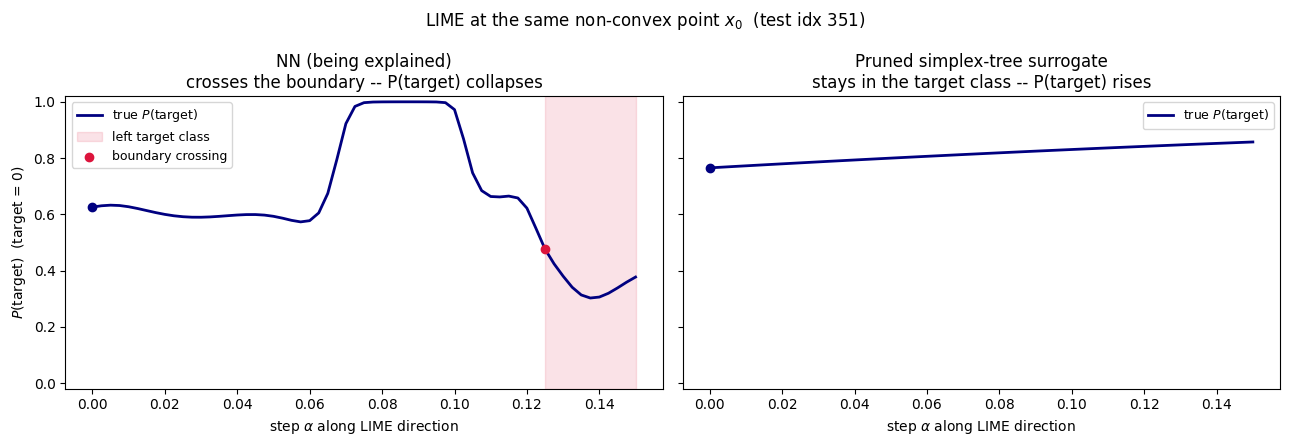

model                            start     min     end   verdict
----------------------------------------------------------------
NN (being explained)             0.626   0.302   0.377   CROSSES boundary (LIME unfaithful)
Pruned simplex-tree surrogate    0.765   0.765   0.857   stays (LIME faithful)


In [17]:
if demo_idx is None:
    print('No demo point to plot.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
    x0 = X_test[demo_idx].astype(np.float32)
    target = int(np.argmax(nn_proba(x0)[0]))
    specs = [('NN (being explained)',          nn_proba, axes[0]),
             ('Pruned simplex-tree surrogate', stc_proba, axes[1])]
    summary = []
    for name, proba_fn, ax in specs:
        a, f_t, g_t, tgt, _, _, am = push(x0, proba_fn, target=target)
        crossed = crosses_boundary(am, target)
        xc = first_crossing(am, target)
        title = (f'{name}\ncrosses the boundary -- P(target) collapses'
                 if crossed else f'{name}\nstays in the target class -- P(target) rises')
        ax.plot(a, f_t, color='navy', lw=2, label=r'true $P(\mathrm{target})$')
        off_mask = np.asarray(am) != target
        if off_mask.any():
            ax.fill_between(a, 0, 1, where=off_mask, color='crimson', alpha=0.12,
                            transform=ax.get_xaxis_transform(), label='left target class')
        ax.scatter([0], [f_t[0]], color='navy', zorder=5)
        if xc is not None:
            ax.scatter([a[xc]], [f_t[xc]], color='crimson', zorder=6, label='boundary crossing')
        ax.set_xlabel(r'step $\alpha$ along LIME direction')
        ax.set_ylim(-0.02, 1.02)
        ax.set_title(title); ax.legend(loc='best', fontsize=9)
        summary.append((name, float(f_t[0]), float(f_t.min()), float(f_t[-1]), crossed))
    axes[0].set_ylabel(r'$P(\mathrm{target})$' + f'  (target = {class_names[target]})')
    plt.suptitle(f'LIME at the same non-convex point $x_0$  (test idx {demo_idx})')
    plt.tight_layout(); plt.show()

    hdr = f'{"model":30s} {"start":>7s} {"min":>7s} {"end":>7s}   verdict'
    print(hdr)
    print('-' * len(hdr))
    for name, s, mn, e, crossed in summary:
        verdict = 'CROSSES boundary (LIME unfaithful)' if crossed else 'stays (LIME faithful)'
        print(f'{name:30s} {s:>7.3f} {mn:>7.3f} {e:>7.3f}   {verdict}')